In [4]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, MaxPooling2D, BatchNormalization
import itertools
from sklearn.metrics import confusion_matrix #imports

In [5]:
cifar10 = tf.keras.datasets.cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data() #carrega os dados
X_train, X_test = X_train / 255.0, X_test / 255.0 #formata
y_train, y_test = y_train.flatten(), y_test.flatten() #joga pra  vetor
X_train.shape

/home/voraztitan/miniconda3/envs/numpylib/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(50000, 32, 32, 3)

In [7]:
y_train.shape #shape de y_train

(50000,)

In [9]:
K = len(set(y_train)) #classes pra prever do y_train
K

10

In [13]:
i = Input(shape = X_train[0].shape) #definindo o input

# x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
# x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
# x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)

#COMENTARIOS QUE ESTAVAM NO CODIGO DO VIDEO, mas sao camadas de convolucao

x = Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(i) #camada de convolução
x = BatchNormalization()(x) #normalizacao dos dados
x = Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(x) #mais uma camada de convolução
x = BatchNormalization()(x) #normalizacao
x = MaxPooling2D((2, 2))(x) #pooling pra diminuir o tamanho e pegar caracteristicas
# x = Dropout(0.2)(x) #dropout comentado do video
x = Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x) #camada de convolução
x = BatchNormalization()(x) #normalizacao
x = Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x) #mais uma camada de convolucao
x = BatchNormalization()(x) #normalizacao pra ir pra proxima camada
x = MaxPooling2D((2, 2))(x) #diminuindo e pegando caracteristicas
# x = Dropout(0.2)(x) #dropout comentado
x = Conv2D(128, (3, 3), activation = 'relu', padding = 'same')(x) #camda de convolucao
x = BatchNormalization()(x) #normaliza
x = Conv2D(128, (3, 3), activation = 'relu', padding = 'same')(x) #mais ma convolucao
x = BatchNormalization()(x) #normalizacao final
x = MaxPooling2D((2, 2))(x) #diminui e pega caracteristicas
# x = Dropout(0.2)(x) 

# x = GlobalMaxPooling2D()(x)
x = Flatten()(x) #coloca os dados de matriz em um vetor
x = Dropout(0.2)(x) #dropout pra desativar 20% dos neuronios
x = Dense(1024, activation = 'relu')(x) #camada densa da rede com relu
x = Dropout(0.2)(x) #mais um dropout
x = Dense(K, activation = 'softmax')(x) #camada de saida usando softmax

model = Model(i, x) #modelo

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy']) #compila o modelo

r = model.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 50) #treina o modelo e valida com teste

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 29ms/step - accuracy: 0.5399 - loss: 1.3266 - val_accuracy: 0.6632 - val_loss: 0.9692
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.7067 - loss: 0.8442 - val_accuracy: 0.7366 - val_loss: 0.7717
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.7615 - loss: 0.6898 - val_accuracy: 0.7339 - val_loss: 0.7789
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.7979 - loss: 0.5842 - val_accuracy: 0.7699 - val_loss: 0.7026
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.8298 - loss: 0.4941 - val_accuracy: 0.7941 - val_loss: 0.6494
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.8538 - loss: 0.4203 - val_accuracy: 0.7852 - val_loss: 0.6546
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.8767 - loss: 0.3562 - val_accuracy: 0.8054 - val_loss: 0.6331
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.8938 -

In [14]:
i = Input(shape = X_train[0].shape) #definindo o input

# x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
# x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
# x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)

#COMENTARIOS QUE ESTAVAM NO CODIGO DO VIDEO, mas sao camadas de convolucao

x = Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(i) #camada de convolução
x = BatchNormalization()(x) #normalizacao dos dados
x = Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(x) #mais uma camada de convolução
x = BatchNormalization()(x) #normalizacao
x = MaxPooling2D((2, 2))(x) #pooling pra diminuir o tamanho e pegar caracteristicas
# x = Dropout(0.2)(x) #dropout comentado do video
x = Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x) #camada de convolução
x = BatchNormalization()(x) #normalizacao
x = Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x) #mais uma camada de convolucao
x = BatchNormalization()(x) #normalizacao pra ir pra proxima camada
x = MaxPooling2D((2, 2))(x) #diminuindo e pegando caracteristicas
# x = Dropout(0.2)(x) #dropout comentado
x = Conv2D(128, (3, 3), activation = 'relu', padding = 'same')(x) #camda de convolucao
x = BatchNormalization()(x) #normaliza
x = Conv2D(128, (3, 3), activation = 'relu', padding = 'same')(x) #mais ma convolucao
x = BatchNormalization()(x) #normalizacao final
x = MaxPooling2D((2, 2))(x) #diminui e pega caracteristicas
# x = Dropout(0.2)(x) 

# x = GlobalMaxPooling2D()(x)
x = Flatten()(x) #coloca os dados de matriz em um vetor
x = Dropout(0.2)(x) #dropout pra desativar 20% dos neuronios
x = Dense(1024, activation = 'relu')(x) #camada densa da rede com relu
x = Dropout(0.2)(x) #mais um dropout
x = Dense(K, activation = 'softmax')(x) #camada de saida usando softmax

model = Model(i, x) #esse é o mesmo codigo anterior soque rodei denovo pra fazer com o data augmentation
 
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [16]:
batch_size = 32 #define o grupo com 32 
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(width_shift_range = 0.1, height_shift_range = 0.1,horizontal_flip = True)
#usa o data augmentation pra rodar a imagem e criar novas a partir dela
train_generator = data_generator.flow(X_train, y_train, batch_size) #gera o grupo de imagens
steps_per_epoch = X_train.shape[0] // batch_size #pra cada epoca quantos batchs sao vistos
r = model.fit(train_generator, validation_data = (X_test, y_test), steps_per_epoch = steps_per_epoch, epochs = 50) #treina o modelo

Epoch 1/50


I0000 00:00:1781106333.809717   96213 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 49s 30ms/step - accuracy: 0.4934 - loss: 1.4419 - val_accuracy: 0.5679 - val_loss: 1.2243
Epoch 2/50
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.7188 - loss: 0.7982

/home/voraztitan/miniconda3/envs/numpylib/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7188 - loss: 0.7982 - val_accuracy: 0.5698 - val_loss: 1.2099
Epoch 3/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.6427 - loss: 1.0188 - val_accuracy: 0.7018 - val_loss: 0.8509
Epoch 4/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8125 - loss: 0.7149 - val_accuracy: 0.7084 - val_loss: 0.8373
Epoch 5/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.7052 - loss: 0.8573 - val_accuracy: 0.7077 - val_loss: 0.8687
Epoch 6/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8750 - loss: 0.5356 - val_accuracy: 0.7058 - val_loss: 0.8803
Epoch 7/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.7384 - loss: 0.7672 - val_accuracy: 0.7450 - val_loss: 0.7471
Epoch 8/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6250 - loss: 0.8996 - val_accuracy: 0.7423 - val_loss: 0.7475
Epoch 9/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.7610 - loss: 0.7018 - val

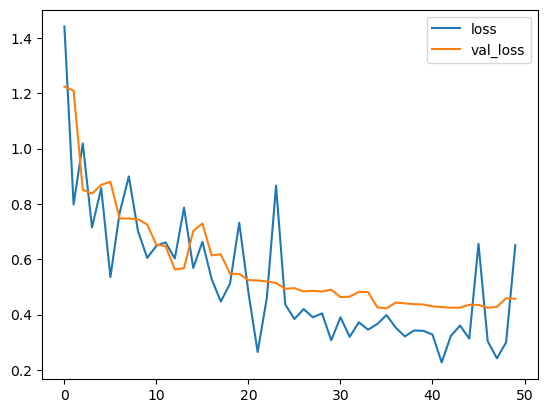

In [17]:
plt.plot(r.history['loss'], label = 'loss')
plt.plot(r.history['val_loss'], label = 'val_loss') #grafico que compara validation loss e loss
plt.legend()

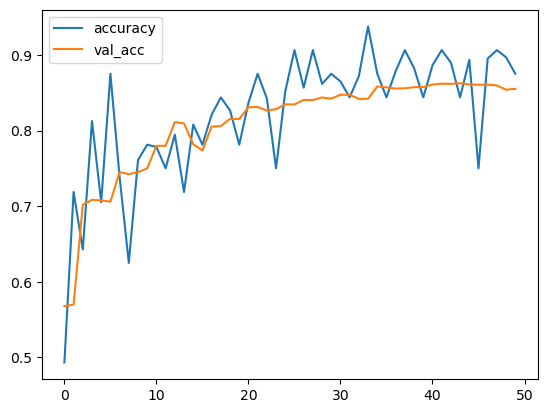

In [18]:
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_acc') #compara acuracia com validation accuracy
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Confusion_matrix, without normalization
[[891  11  20   4   3   2   9   4  36  20]
 [  0 943   2   1   0   0   2   0  27  25]
 [ 44   3 789  17  19  32  72  10   9   5]
 [ 21  10  43 651  34  89 113  16  14   9]
 [ 15   1  57  21 802   8  77  16   3   0]
 [  4   4  26  85  19 771  62  20   7   2]
 [  4   3  17  11   2   3 959   0   0   1]
 [ 10   0  14  12  22  29  21 884   3   5]
 [ 24   5   3   3   1   1   7   0 948   8]
 [  9  46   4   3   1   0   4   1  19 913]]


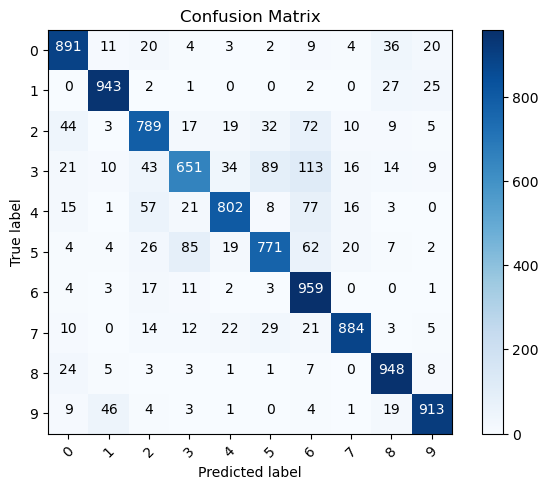

In [19]:
def plot_confusion_matrix(cm, classes, normalize = False, title = 'Confusion Matrix', cmap = plt.cm.Blues): #funcao pra mostrar a matriz de confusao
    if normalize: #se normaliza
        cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis] #joga os valores pra porcentagens
        print('Normalized Confusion Matrix')
    else: 
        print('Confusion_matrix, without normalization')

    print(cm) #mostra os valores 

    plt.imshow(cm, interpolation = 'nearest', cmap = cmap) #define a matriz colorida
    plt.title(title) #titulo
    plt.colorbar() #tons de azul q esta no parametro
    tick_marks = np.arange(len(classes)) #classes
    plt.xticks(tick_marks, classes, rotation = 45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd' #formatacao do texto
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment = 'center', color = 'white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show() #mostra

p_test = model.predict(X_test).argmax(axis = 1) #faz o teste
cm = confusion_matrix(y_test, p_test) #dados
plot_confusion_matrix(cm, list(range(10))) #chama a funcao pra fazer a imagem da matriz

In [20]:
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split() #diviindo labels

Text(0.5, 1.0, 'True label: truck Predicted: automobile')

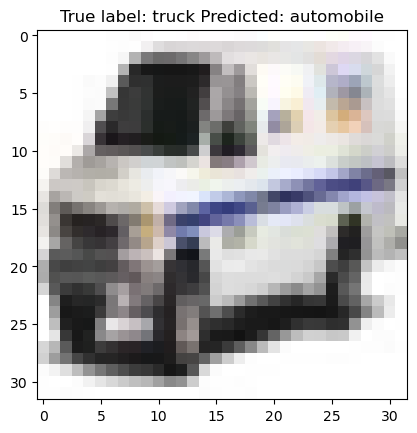

In [21]:
misclassified_idx = np.where(p_test != y_test)[0] #pega as imagens q foram prevista errada
i = np.random.choice(misclassified_idx) #pega uma aletaoriamente
plt.imshow(X_test[i], cmap = 'gray') 
plt.title('True label: %s Predicted: %s' % (labels[y_test[i]], labels[p_test[i]])) #nome real da classe

In [22]:
model.summary() #vendo o modelo por sumario

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,189,888 (27.43 MB)

 Trainable params: 2,396,330 (9.14 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 4,792,662 (18.28 MB)